# Target Leakage Audit

**Goal**:  Identify & eliminate information leakage that would inflate model performance

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Load Data

In [3]:
df = pd.read_parquet('../data/generated/sales_data.parquet')
df['date'] = pd.to_datetime(df['date'])

print(f"Dataset Shape: {df.shape}")
print(f"Date Range: {df['date'].min()} - {df['date'].max()}")
print(f"Total Rows: {len(df)}")
print(f"Unique Stores: {df['store_id'].nunique()}")
print(f"Unique Products: {df['product'].nunique()}")
print(f"Columns: {df.shape[1]}")
print(f"Missing Values: {df.isnull().sum().sum()} total")

print("=========================================")
print(df.head())

Dataset Shape: (2883231, 55)
Date Range: 2016-01-01 00:00:00 - 2026-08-26 00:00:00
Total Rows: 2883231
Unique Stores: 37
Unique Products: 27
Columns: 55
Missing Values: 0 total
        date       region    city       store  store_id  \
0 2016-01-01  Maharashtra  Mumbai  Bandra Hub         1   
1 2016-01-01  Maharashtra  Mumbai  Bandra Hub         1   
2 2016-01-01  Maharashtra  Mumbai  Bandra Hub         1   
3 2016-01-01  Maharashtra  Mumbai  Bandra Hub         1   
4 2016-01-01  Maharashtra  Mumbai  Bandra Hub         1   

                 product    brand     category  price  discount  ...  \
0  Samsung Electronics 1  Samsung  Electronics  29429        10  ...   
1  Samsung Electronics 2  Samsung  Electronics  46485         5  ...   
2  Samsung Electronics 3  Samsung  Electronics  27684         0  ...   
3     Sony Electronics 2     Sony  Electronics  57529         5  ...   
4       LG Electronics 1       LG  Electronics  32991        10  ...   

   salary_week_flag  supplier_lead_

## 2. Define Target & Prediction Boundary

In [4]:
TARGET = 'demand'

# Split data
train_pct = 0.9
split_date = df['date'].quantile(train_pct)

train_df = df[df['date'] < split_date].copy()
test_df = df[df['date'] >= split_date].copy()

print(f"TARGET VARIABLE: {TARGET}")
print(f"\n Train/Test Split:")
print(f"Train: {train_df['date'].min()} -> {train_df['date'].max()} ({len(train_df):,}) rows")
print(f"Test: {test_df['date'].min()} -> {test_df['date'].max()} ({len(train_df):,}) rows")
print(f"Train %: {len(train_df) / len(df) * 100:.1f}%")
print(f"Test %: {len(test_df)/ len(df) * 100:.1f} %")

TARGET VARIABLE: demand

 Train/Test Split:
Train: 2016-01-01 00:00:00 -> 2025-08-01 00:00:00 (2,594,241) rows
Test: 2025-08-02 00:00:00 -> 2026-08-26 00:00:00 (2,594,241) rows
Train %: 90.0%
Test %: 10.0 %


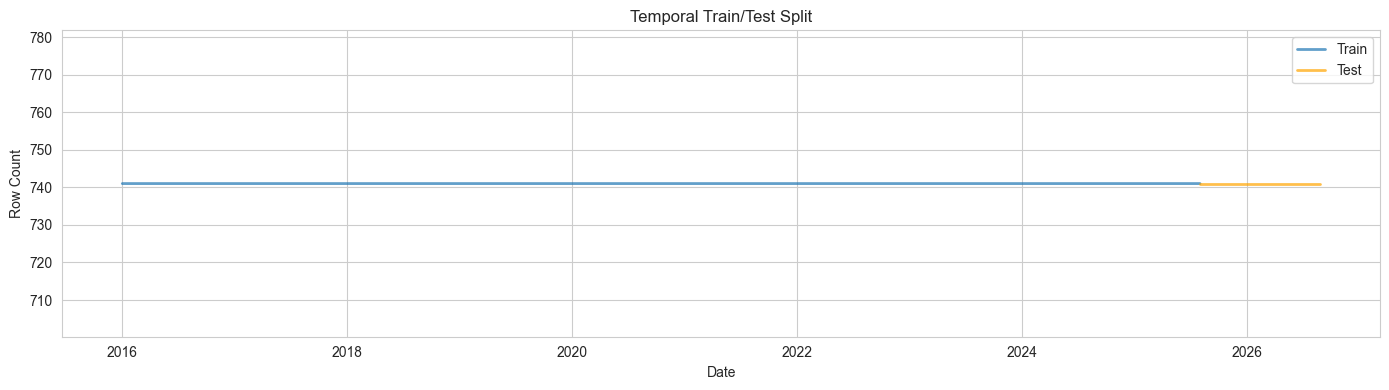

In [5]:
# Visualize temporal split
plt.figure(figsize = (14, 4))
train_dates = train_df.groupby('date').size()
test_dates = test_df.groupby('date').size()

plt.plot(train_dates.index, train_dates.values, label = 'Train', linewidth = 2, alpha = 0.7)
plt.plot(test_dates.index, test_dates.values, label = 'Test', linewidth = 2, alpha = 0.7, color = 'orange')
plt.xlabel('Date')
plt.ylabel('Row Count')
plt.title('Temporal Train/Test Split')
plt.legend()
plt.tight_layout()
plt.show()

## 3. Check Date Contamination

In [8]:
# AUDIT: Do train & test dates overlap?
train_min, train_max = train_df['date'].min(), train_df['date'].max()
test_min, test_max = test_df['date'].min(), test_df['date'].max()

print("CHECK #1: Date Contamination")
print(f"="*60)

if train_max >= test_min:
    print(f"FAIL: Train max ({train_max.date()}) >= Test min({test_min.date()})")
    print(f"Overlap period: {test_min.date()} to {train_max.date()}")
    overlapping_rows = len(df[(df['date'] >= test_min) & (df['date'] <= train_max)])
    print(f"Contaminated rows: {overlapping_rows}")
    data_leakage = True
else:
    print(f"PASS: Clean temporal split")
    print(f"Train ends: {train_max.date()}")
    print(f"Test Starts: {test_min.date()}")
    data_leakage = False

print(f"\nGap between train & test: {(test_min -  train_max).days} days")

CHECK #1: Date Contamination
PASS: Clean temporal split
Train ends: 2025-08-01
Test Starts: 2025-08-02

Gap between train & test: 1 days


## 4. Check for Outcome-Dependent Features

In [10]:
outcome_dependent = ['sales', 'sales_qty', 'lost_sales']

print("CHECK 2: Outcome Dependent Features")
print(f"=" * 60)
print(f"TARGET: {TARGET}")
print(f"\n Dangeous Columns (depend on target):")

risky_features = []
for col in outcome_dependent:
    if col in df.columns and col != TARGET:
        print(f"\n ❌️ {col}")
        print(f"Why: {col} is calculated from/with {TARGET}")
        if col == 'sales':
            print(f"Formula: sales_qty * final_price")
        elif col == 'lost_sales':
            print("Formula: max(0, demand - inventory)")
        print(f"ACTION: REMOVE before modelling")
        risky_features.append(col)
    
if not risky_features:
    print("✅️ PASS: No outcome-dependent features detected")

outcome_leakage = len(risky_features) >0

CHECK 2: Outcome Dependent Features
TARGET: demand

 Dangeous Columns (depend on target):

 ❌️ sales
Why: sales is calculated from/with demand
Formula: sales_qty * final_price
ACTION: REMOVE before modelling

 ❌️ sales_qty
Why: sales_qty is calculated from/with demand
ACTION: REMOVE before modelling

 ❌️ lost_sales
Why: lost_sales is calculated from/with demand
Formula: max(0, demand - inventory)
ACTION: REMOVE before modelling


## 5. Check for Future Information

In [12]:
print(f"CHECK 3: Future Information")
print(f"="*60)

future_keywords = ['tomorrow', 'next_', 'future', '_forecast', 'predicted_', 'ahead']
future_features = []

for col in df.columns:
    if any(kw in col.lower() for kw in future_keywords):
        future_keywords.append(col)
        print(f"❌️ {col}")
        print(f"Contains future information")
        print("ACTION: Use lagged/historical version\n")

if not future_features:
    print("✅️ PASS: No future information detected")
    future_leakage = False
else:
    print(f"\n Found {len(future_features)} future-looking features")
    future_leakage = True

CHECK 3: Future Information
✅️ PASS: No future information detected


## 6. Check for Global Statistics Contamination

In [13]:
print(f"CHECK 4: Global Statistics Contamination")
print(f"="*60)

static_feature_examples = ['avg_basket_size', 'foot_traffic_index', 'population_density']

print("Features that need TRAIN-ONLY Calculation:\n")

global_stats_issues = []
for col in static_feature_examples:
    if col in df.columns:
        # These should be static
        train_stats = train_df.groupby('store_id')[col].nunique()
        has_variation = (train_stats > 1).any()

        if not has_variation:
            print(f"✅️ {col}: Static (SAFE)")
        else:
            print(f"⚠️ {col}: TIME-VARYING (needs historical average)")
            global_stats_issues.append(col)

print(f"\n ACTION: Before prediction, recalculate all store/city attributes using TRAIN data only:")
print(f"\n Example (Don't Do This):")
print(f" >>> avg_basket = df.groupby('store_id)['avg_basket_size].mean() # WRONG - includes test")
print(f"\n Example (DO THIS):")
print(f" >>> avg_basket = train_df.groupby('store_id')['avg_basket_size].mean() # OK - train only")

global_stats_leakage = len(global_stats_issues) >0

CHECK 4: Global Statistics Contamination
Features that need TRAIN-ONLY Calculation:

✅️ avg_basket_size: Static (SAFE)
✅️ foot_traffic_index: Static (SAFE)
✅️ population_density: Static (SAFE)

 ACTION: Before prediction, recalculate all store/city attributes using TRAIN data only:

 Example (Don't Do This):
 >>> avg_basket = df.groupby('store_id)['avg_basket_size].mean() # WRONG - includes test

 Example (DO THIS):
 >>> avg_basket = train_df.groupby('store_id')['avg_basket_size].mean() # OK - train only
